In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import math
import random
import numpy as np
import torch as ch
from glob import glob
from copy import deepcopy
from collections import Counter
from IPython.display import display

import sys
sys.path.append("../src/")
import utils
import matplotlib.pyplot as plt
from robustness_analyzer import RobustnessAnalyzer


from pytorch3d.io import load_obj 

### Camera Perturbation

In [4]:
data_dir = "../data"

# Envmap(s) we're using during optimization (one or more)
envmap_paths = glob(os.path.join("../data", "environments_road/*"))[::10]
#envmap_paths = ["../data/environments/goegap_road_2k.exr"]  # This would generate background-neutral (white) renders

true_class = 'tank, army tank, armored combat vehicle, armoured combat vehicle'
target_class = true_class
 
object_dir = "tank"

params_to_optimize = ["camera"]

kwargs = {
    "obj_path": os.path.join(data_dir, object_dir, "combined_rotated.obj"),
    "texture_path": None,
    "envmap_paths": envmap_paths,
    "target_class": target_class,
    "batch_size": 8,  # How many different viewpoints we're optimizing in parallel (* #Environments)
    "params_to_optimize": params_to_optimize,
    "targeted": target_class!=true_class,
    "positive_z": True # constraints camera z>0 (positive elevation)
}

robust_analyzer = RobustnessAnalyzer(**kwargs)

#### Run optimization: This will generate num_runs*batch_size viewpoints
results_camera = robust_analyzer.run(num_runs=3, num_iterations=300, lr=1e-3)

Loss: 1.48 - Class: tank, army tank... - 'adv acc': 3/8 - Avg Prob: 0.5806 - LR: 1.00e-03: 100%|████████████████████████| 300/300 [01:01<00:00,  4.86it/s]
Loss: 2.00 - Class: tank, army tank... - 'adv acc': 5/8 - Avg Prob: 0.2487 - LR: 1.00e-03: 100%|████████████████████████| 300/300 [01:03<00:00,  4.76it/s]
Loss: 3.62 - Class: tank, army tank... - 'adv acc': 6/8 - Avg Prob: 0.2277 - LR: 1.00e-03: 100%|████████████████████████| 300/300 [01:00<00:00,  4.95it/s]


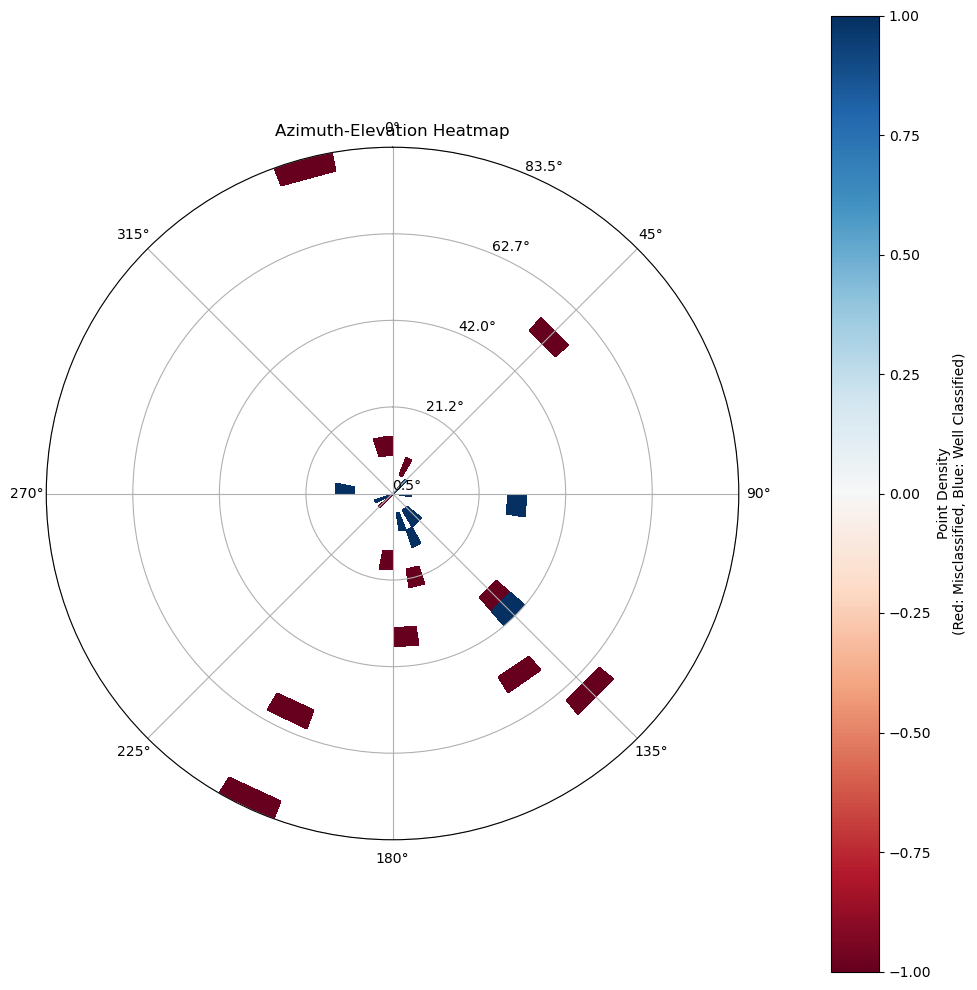

In [7]:
labels_correct = ch.stack(results_camera["final_logits"]).reshape(-1, 1000).argmax(1) == utils.get_idx(true_class)

camera_positions = ch.stack([x["camera"] for x in results_camera["final_scene_params"]]).reshape(-1, 3)\
                        .repeat_interleave(len(envmap_paths) or 1, dim=0)
utils.visualize_positions_polar(camera_positions, labels_correct)

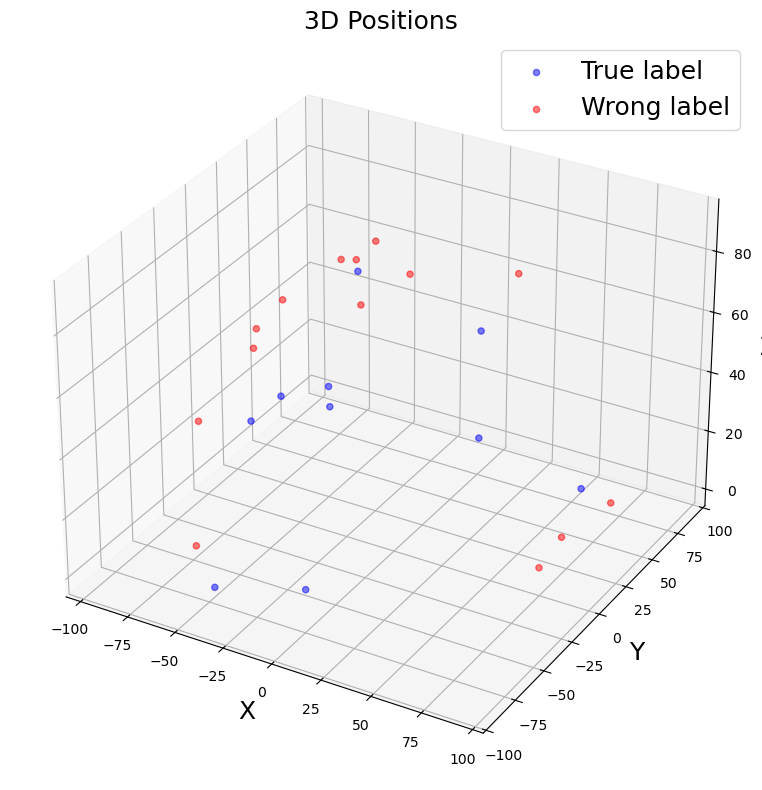

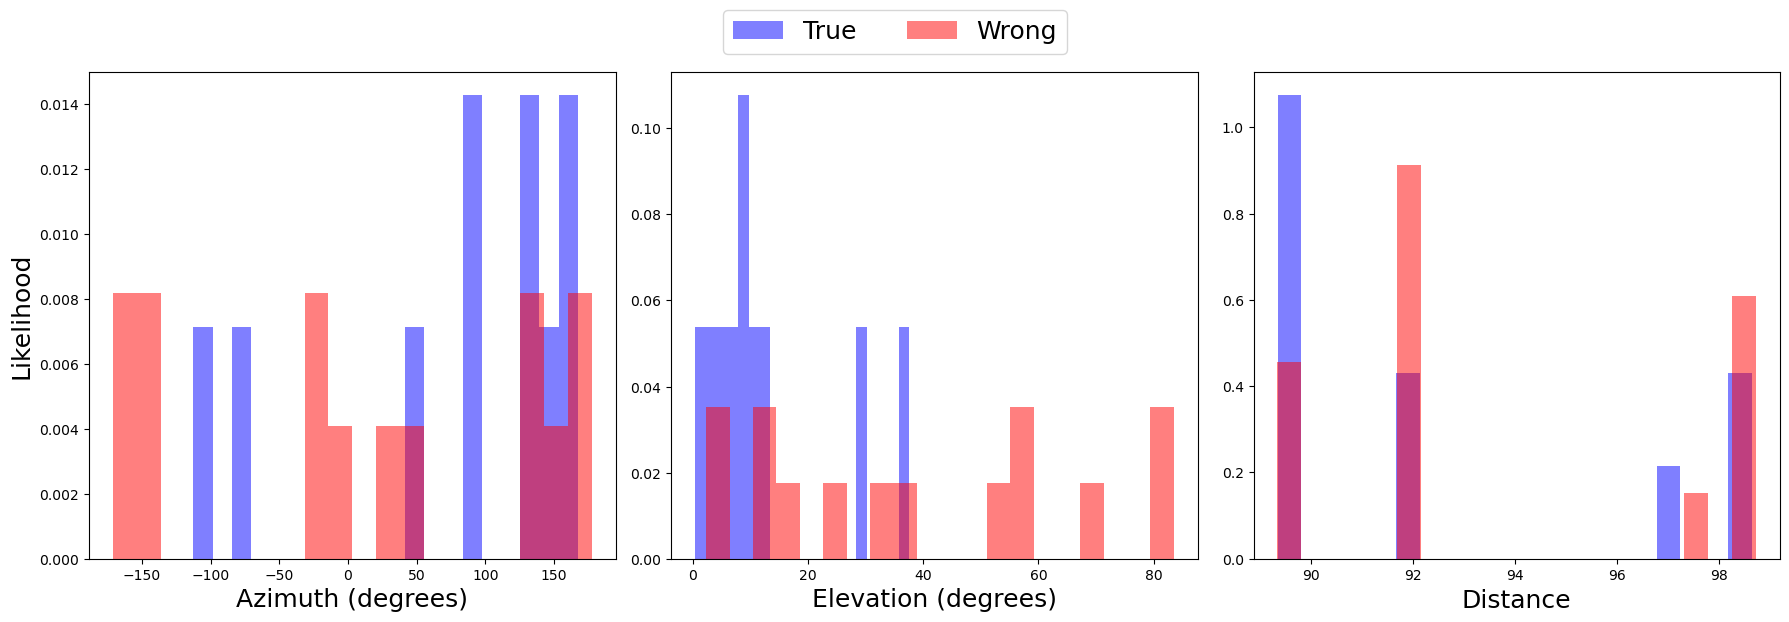

In [9]:
utils.visualize_positions_with_distributions(camera_positions, labels_correct)

If we want to re-render a specific output we can do it this way, here showing specific examples from the problematic areas from the distribution for Azimuth

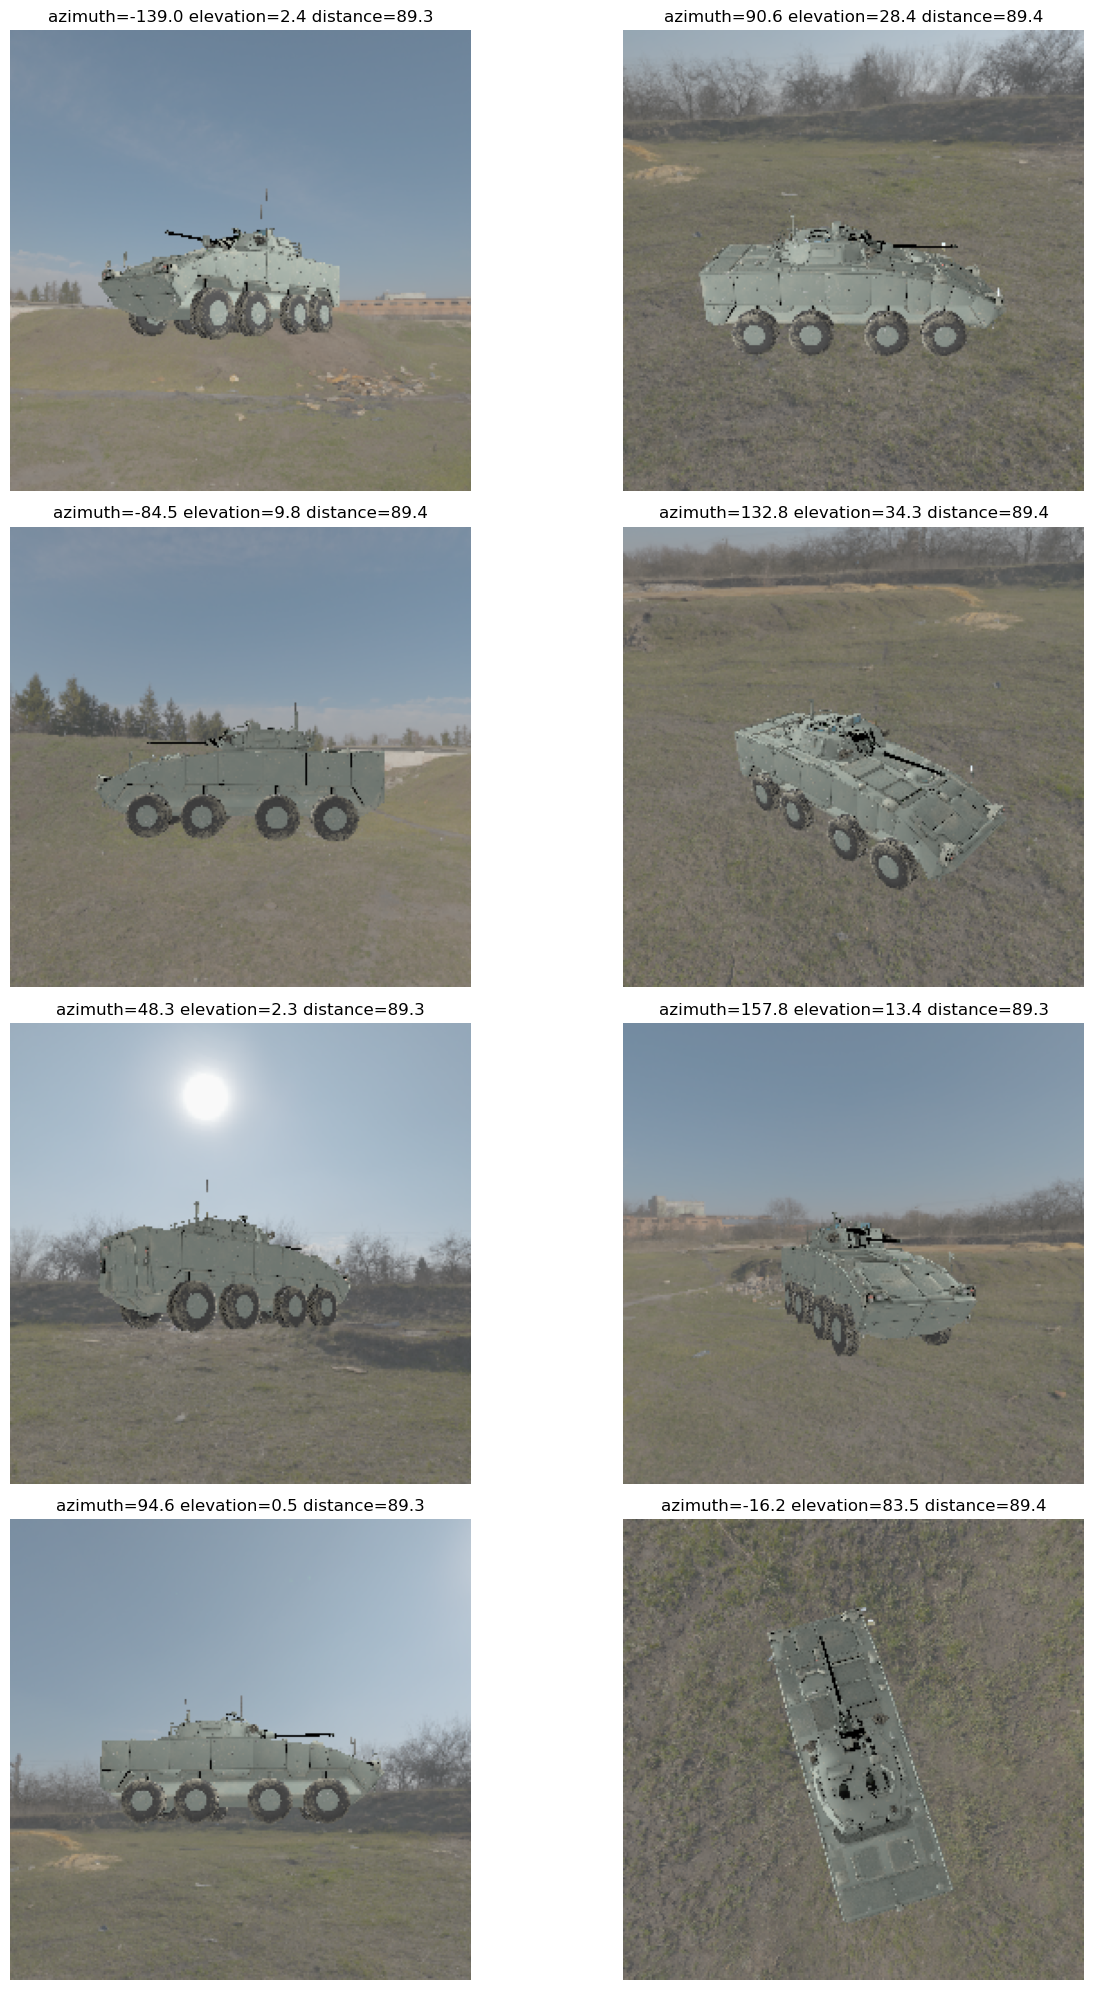

In [40]:
run_nb = 0
model = robust_analyzer.model

model.update_scene_params(results_camera["final_scene_params"][run_nb])
render_ims = model.render(image_res=256, with_grad=False)

env_nb = 0
im_indices = range(model.batch_size)

max_cols = 2
n_images = len(im_indices)
n_rows = math.ceil(n_images / max_cols)

fig, axes = plt.subplots(n_rows, max_cols, figsize=(max_cols * 7, n_rows * 5))
axes = axes.flatten() if n_images > 1 else [axes]

for ax, im_idx in zip(axes, im_indices):
    title = " ".join([
        f"{metric}={x.item():.1f}"
        for x, metric in zip(
            utils.compute_spherical_coordinates(results_camera["final_scene_params"][run_nb]["camera"][im_idx][None]),
            ["azimuth", "elevation", "distance"]
        )
    ])
    ax.imshow(utils.to_numpy(render_ims[im_idx][env_nb]))
    ax.axis("off")
    ax.set_title(title)

for ax in axes[len(im_indices):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [41]:
utils.create_logits_comparison_table(all_results={"camera": results_camera})